In [1]:
# os 환경 변수 GEMINI API KEY 입력
from dotenv import load_dotenv

load_dotenv()

True

# Command with Goto

### Model & Tool 정의

In [15]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage
from langgraph.types import interrupt
from langgraph.types import Command

model = init_chat_model("gpt-5-nano")

### State 정의

In [3]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    selected_menu: str # 선택된 메뉴 저장

/Users/dohyunkim/Documents/langchain-study/langgraph/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### Node 정의

In [4]:
# [Node 1] 메뉴 추천
def recommender_node(state: ChatState):
    # 현재 상태(이전에 추천했던 메뉴)를 확인
    last_menu = state.get("selected_menu")

    # 만약 이전에 A코스를 추천했다면 -> 거절당하고 다시 온 것이므로 B코스 추천
    if last_menu == "A 코스 (20만원)":
        print("\n🍣 [Recommender] 그렇다면. 실속형 'B 코스 (8만원)'을 추천합니다.")
        return {"selected_menu": "B 코스 (8만원)"}

    # 기본(최초) 추천
    else:
        print("\n🍣 [Recommender] 쉐프 추천: 'A 코스 (20만원)'")
        return {"selected_menu": "A 코스 (20만원)"}

In [5]:

# [Node 2] 승인/거절 및 경로 변경 (Router 역할 겸임)
def human_approval_node(state: ChatState):
    menu = state["selected_menu"]

    print(f"\n👮 [Approval] '{menu}'은(는) 고가이므로 승인이 필요합니다.")

    # 1. 멈추고 물어봄 (Dynamic Interrupt)
    # 멈춘 후 Command(resume="yes" 또는 "no")로 전달된 값이 approved 변수에 들어옵니다.
    approved = interrupt(f"'{menu}' 예약을 진행하시겠습니까? (yes/no)")

    # 2. [핵심] 답변에 따라 즉시 순간이동 (Command with goto)
    if approved == "yes":
        print("▶️ [Decision] 승인됨 -> 예약 확정으로 이동")

        # update: 상태 업데이트 (예약 승인 로그 남기기)
        # goto: 다음 실행할 노드 이름 명시
        return Command(
            update={"messages": ["사용자가 예약을 승인했습니다."]},
            goto="booking",  # booking 노드로 즉시 점프!
        )

    else:
        print("▶️ [Decision] 거절됨 -> 다시 추천받으러 이동")

        return Command(
            update={"messages": ["사용자가 거절했습니다. 다른 메뉴를 찾습니다."]},
            goto="recommender",  # recommender 노드로 즉시 점프!
        )


In [6]:
# [Node 3] 예약 확정 (승인 시 이동할 곳)
def booking_node(state: ChatState):
    menu = state["selected_menu"]
    print(f"\n✅ [Booking] '{menu}' 예약이 확정되었습니다! (문자 발송 완료)")
    return {"messages": [f"'{menu}' 예약 완료"]}

### 그래프 생성

In [7]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(ChatState)

workflow.add_node("recommender", recommender_node)
workflow.add_node("approval", human_approval_node)
workflow.add_node("booking", booking_node)

In [8]:
workflow.add_edge(START, "recommender")
workflow.add_edge("recommender", "approval")

In [9]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [10]:
app = workflow.compile(checkpointer=checkpointer)

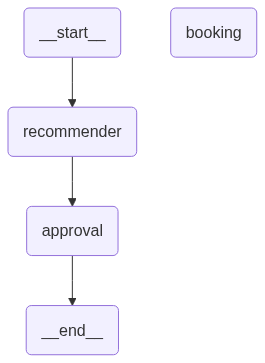

In [11]:
app

In [12]:
config = {"configurable": {"thread_id": "goto-demo"}}

In [16]:
app.invoke({"messages": [HumanMessage(content="예약해줘")]}, config=config)


🍣 [Recommender] 그렇다면. 실속형 'B 코스 (8만원)'을 추천합니다.

👮 [Approval] 'B 코스 (8만원)'은(는) 고가이므로 승인이 필요합니다.


{'messages': [HumanMessage(content='예약해줘', additional_kwargs={}, response_metadata={}, id='5f7802b8-e63b-4378-9c88-23126a5d051f'),
  HumanMessage(content='예약해줘', additional_kwargs={}, response_metadata={}, id='ece207fe-164c-4444-8ce6-df781c92a18a')],
 'selected_menu': 'B 코스 (8만원)',
 '__interrupt__': [Interrupt(value="'B 코스 (8만원)' 예약을 진행하시겠습니까? (yes/no)", id='388a8278d76a9b261e22c1672cf6b9c6')]}

In [17]:
snapshot = app.get_state(config)
print(f"⚠️ 대기 중: {snapshot.tasks[0].interrupts[0].value}")

⚠️ 대기 중: 'B 코스 (8만원)' 예약을 진행하시겠습니까? (yes/no)


In [18]:
app.invoke(Command(resume="no"), config=config)


👮 [Approval] 'B 코스 (8만원)'은(는) 고가이므로 승인이 필요합니다.
▶️ [Decision] 거절됨 -> 다시 추천받으러 이동

🍣 [Recommender] 쉐프 추천: 'A 코스 (20만원)'

👮 [Approval] 'A 코스 (20만원)'은(는) 고가이므로 승인이 필요합니다.


{'messages': [HumanMessage(content='예약해줘', additional_kwargs={}, response_metadata={}, id='5f7802b8-e63b-4378-9c88-23126a5d051f'),
  HumanMessage(content='예약해줘', additional_kwargs={}, response_metadata={}, id='ece207fe-164c-4444-8ce6-df781c92a18a'),
  HumanMessage(content='사용자가 거절했습니다. 다른 메뉴를 찾습니다.', additional_kwargs={}, response_metadata={}, id='2d74deb3-4313-494c-a1b4-d7740ee49090')],
 'selected_menu': 'A 코스 (20만원)',
 '__interrupt__': [Interrupt(value="'A 코스 (20만원)' 예약을 진행하시겠습니까? (yes/no)", id='0efba3fbdc5ed0bb6ae9b8bc65cec099')]}

In [19]:
snapshot = app.get_state(config)
print(f"{snapshot.tasks[0].interrupts[0].value}")

'A 코스 (20만원)' 예약을 진행하시겠습니까? (yes/no)


In [20]:
result = app.invoke(Command(resume="yes"), config=config)


👮 [Approval] 'A 코스 (20만원)'은(는) 고가이므로 승인이 필요합니다.
▶️ [Decision] 승인됨 -> 예약 확정으로 이동

✅ [Booking] 'A 코스 (20만원)' 예약이 확정되었습니다! (문자 발송 완료)


In [21]:
result['messages'][-1].content

"'A 코스 (20만원)' 예약 완료"

# Command with Goto (실습)

### Model & Tool 정의

### State 정의

### Node 정의

### 그래프 생성